In [3]:
import pandas as pd

crime = pd.read_csv("data/cleaned_crime_long.csv", parse_dates=["Date"])

london_monthly = crime.groupby("Date")["CrimeCount"].sum()

print(london_monthly.shape)
print(london_monthly.head())
print(london_monthly.tail())

(191,)
Date
2010-04-01    66476
2010-05-01    68563
2010-06-01    69265
2010-07-01    70526
2010-08-01    65310
Name: CrimeCount, dtype: int64
Date
2025-10-01    76963
2025-11-01    76013
2025-12-01    73393
2026-01-01    70305
2026-02-01    67469
Name: CrimeCount, dtype: int64


In [4]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(london_monthly)

print("ADF statistic:", result[0])
print("p-value:", result[1])

ADF statistic: -1.3522257922123488
p-value: 0.6049535124838835


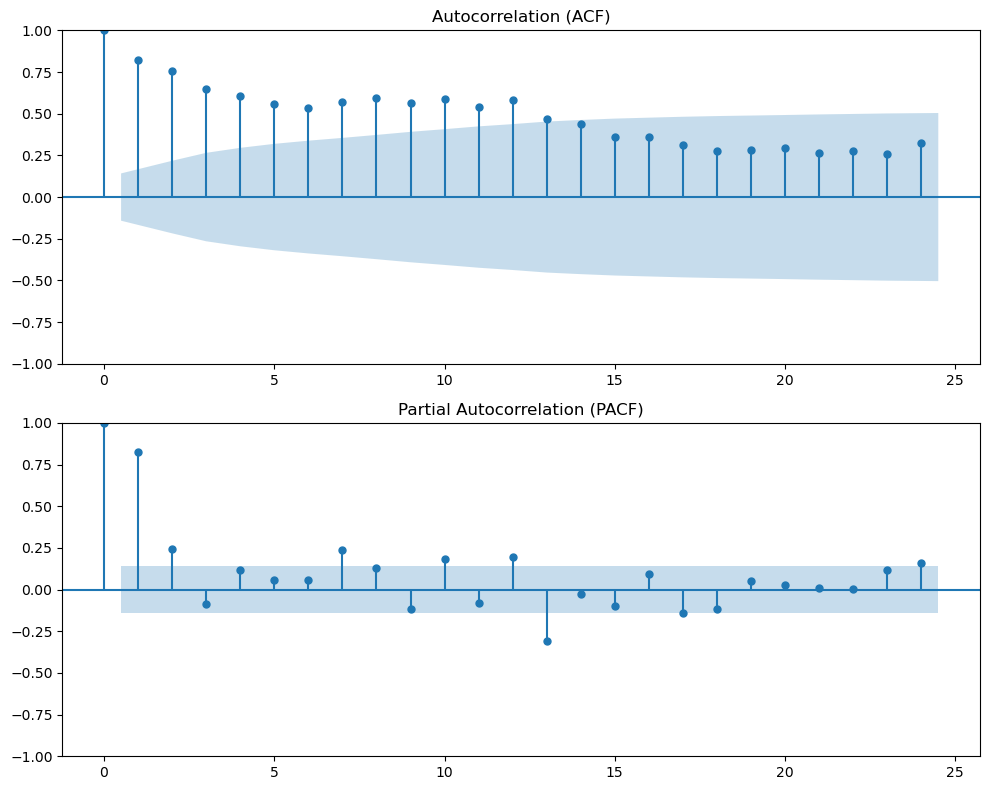

In [5]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import os

os.makedirs("figures", exist_ok=True)

fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(london_monthly, lags=24, ax=axes[0])
axes[0].set_title("Autocorrelation (ACF)")

plot_pacf(london_monthly, lags=24, ax=axes[1])
axes[1].set_title("Partial Autocorrelation (PACF)")

plt.tight_layout()
plt.savefig("figures/06_acf_pacf.png", dpi=150)
plt.show()

count      191.000000
mean     67039.507853
std       7167.395406
min      48044.000000
25%      61277.500000
50%      67090.000000
75%      73071.500000
max      82509.000000
Name: CrimeCount, dtype: float64

Skewness: -0.0977977280677298


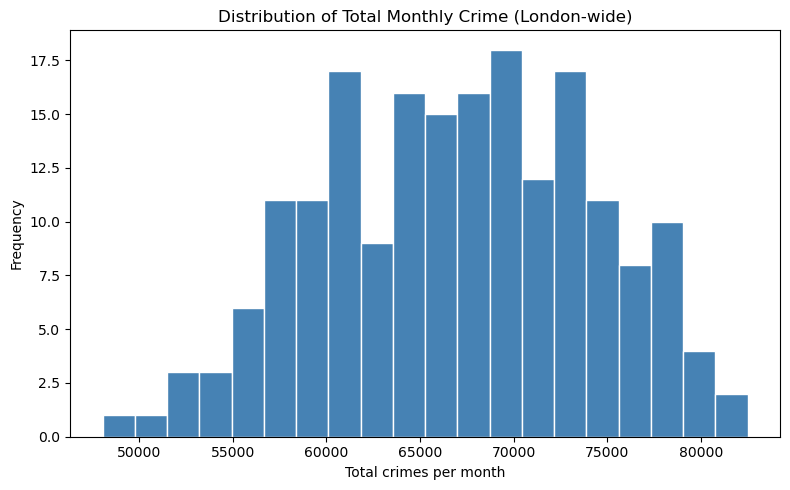

In [6]:
print(london_monthly.describe())

print("\nSkewness:", london_monthly.skew())

plt.figure(figsize=(8, 5))
plt.hist(london_monthly, bins=20, color="steelblue", edgecolor="white")
plt.title("Distribution of Total Monthly Crime (London-wide)")
plt.xlabel("Total crimes per month")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("figures/07_distribution.png", dpi=150)
plt.show()

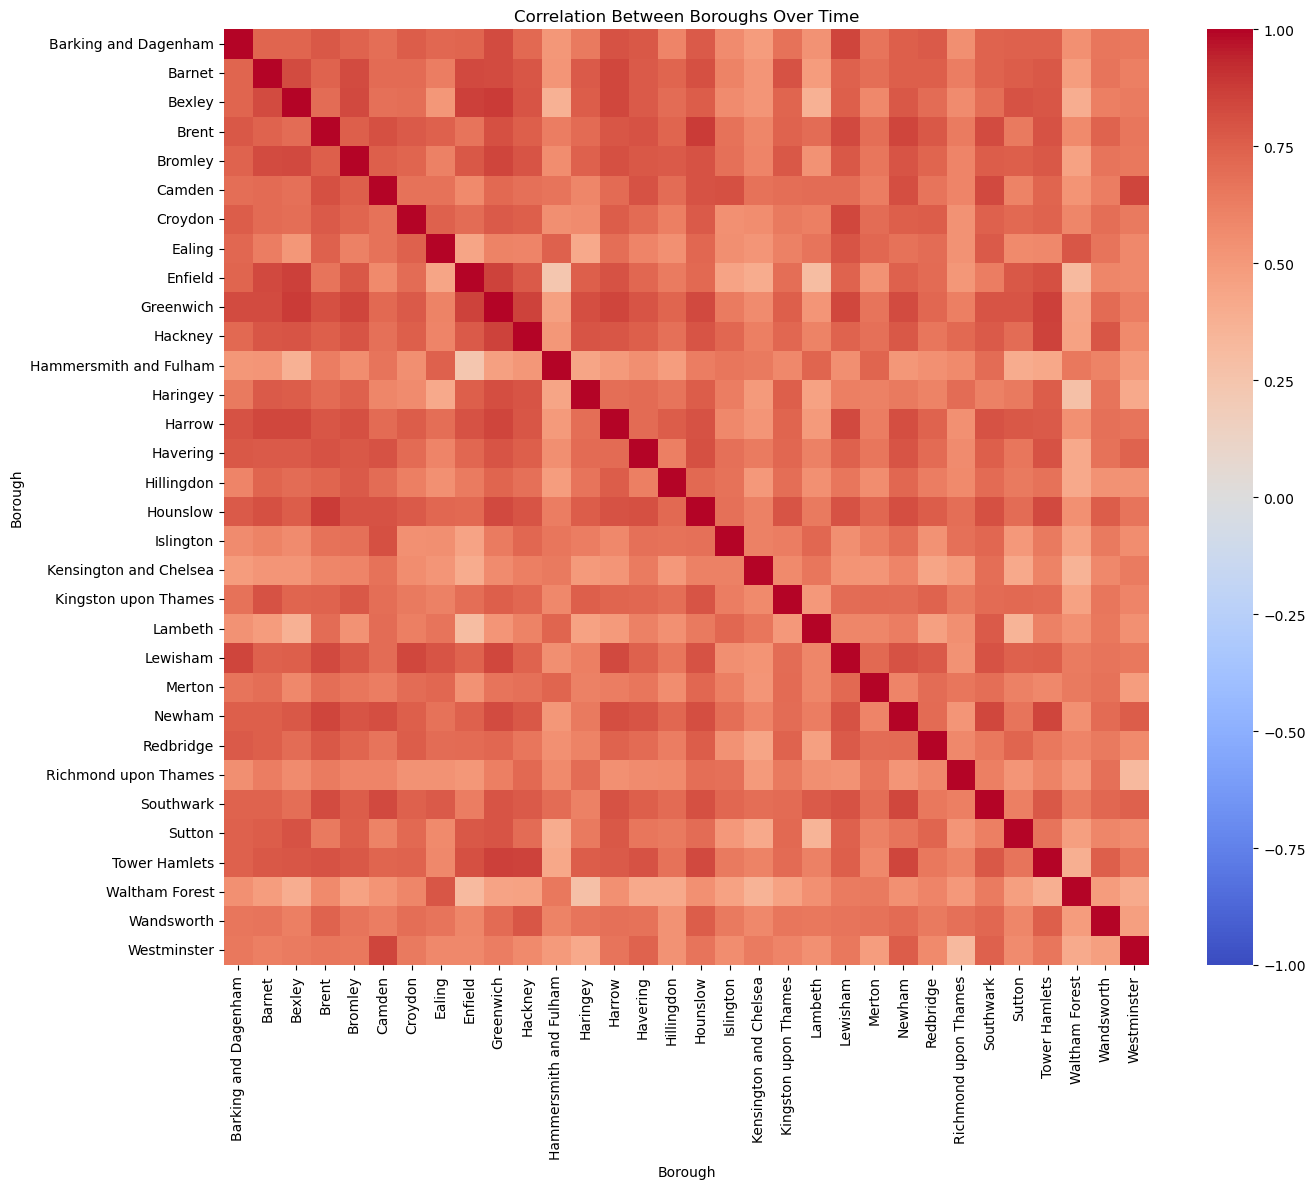

In [7]:
import seaborn as sns
borough_monthly = crime.groupby(["Borough", "Date"])["CrimeCount"].sum().reset_index()
borough_wide = borough_monthly.pivot(index="Date", columns="Borough", values="CrimeCount")

corr_matrix = borough_wide.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation Between Boroughs Over Time")
plt.tight_layout()
plt.savefig("figures/08_borough_correlation.png", dpi=150)
plt.show()

In [8]:
borough_stats = crime.groupby("Borough")["CrimeCount"].agg(
    Mean="mean",
    Std="std",
    Min="min",
    Max="max",
    Total="sum"
).round(2)

borough_stats["CV"] = (borough_stats["Std"] / borough_stats["Mean"]).round(3)

borough_stats = borough_stats.sort_values("Total", ascending=False)

print(borough_stats)

                          Mean     Std  Min   Max    Total     CV
Borough                                                          
Westminster             166.35  336.97    0  4101  1016724  2.026
Lambeth                  89.25  106.41    0   625   545492  1.192
Southwark                89.55  109.24    0   723   545172  1.220
Camden                   88.65  132.25    0   977   541821  1.492
Newham                   87.76  103.11    0   538   534285  1.175
Croydon                  82.10   98.50    0   613   499815  1.200
Tower Hamlets            80.84   92.51    0   585   494097  1.144
Hackney                  77.94   91.49    0   517   474483  1.174
Ealing                   76.18   91.69    0   499   465616  1.204
Brent                    74.50   88.89    0   487   455353  1.193
Islington                71.83   88.78    0   711   438997  1.236
Haringey                 70.96   82.84    0   425   431997  1.167
Barnet                   68.88   84.20    0   439   420968  1.222
Lewisham  

In [9]:
category_stats = crime.groupby("MajorCategory")["CrimeCount"].agg(
    Mean="mean",
    Std="std",
    Min="min",
    Max="max",
    Total="sum"
).round(2)

category_stats["CV"] = (category_stats["Std"] / category_stats["Mean"]).round(3)
category_stats = category_stats.sort_values("Total", ascending=False)

print(category_stats)

                                        Mean     Std  Min   Max    Total  \
MajorCategory                                                              
THEFT                                 149.10  197.44    0  4101  3645128   
VIOLENCE AGAINST THE PERSON            99.89  103.59    0   577  3052596   
VEHICLE OFFENCES                       64.22   69.77    0   439  1570059   
BURGLARY                               47.39   60.04    0   397  1124356   
ARSON AND CRIMINAL DAMAGE              76.16   77.80    0   351   930925   
DRUG OFFENCES                          60.33   65.11    0   684   737459   
PUBLIC ORDER OFFENCES                  27.77   34.37    0   255   675499   
ROBBERY                                38.77   47.69    0   424   473953   
SEXUAL OFFENCES                        22.22   14.39    0   219   271675   
MISCELLANEOUS CRIMES AGAINST SOCIETY   26.35   16.94    2   215   161077   
POSSESSION OF WEAPONS                  15.17    8.93    0    78    92728   
FRAUD AND FO

In [10]:
borough_stats.to_csv("data/borough_descriptive_stats.csv")
category_stats.to_csv("data/category_descriptive_stats.csv")

print("Saved both tables!")

Saved both tables!
